In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('datasets/Lead Scoring.csv')

In [3]:
data.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [4]:
data.isna().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

In [5]:
# useless column
data.drop(['Prospect ID','Lead Number'], axis=1, inplace=True)

In [6]:
# constant column
data.drop(['Do Not Call','Search','Magazine','Newspaper Article','X Education Forums','Newspaper','Digital Advertisement',
           'Receive More Updates About Our Courses','Update me on Supply Chain Content','Get updates on DM Content',
          'I agree to pay the amount through cheque'], axis=1, inplace=True)

In [7]:
# taking only important column
data = data[['Lead Origin','Lead Source','TotalVisits','Total Time Spent on Website','Page Views Per Visit','Last Activity',
            'Specialization','What is your current occupation','Tags','Lead Quality','Last Notable Activity','Converted']]

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Lead Origin                      9240 non-null   object 
 1   Lead Source                      9204 non-null   object 
 2   TotalVisits                      9103 non-null   float64
 3   Total Time Spent on Website      9240 non-null   int64  
 4   Page Views Per Visit             9103 non-null   float64
 5   Last Activity                    9137 non-null   object 
 6   Specialization                   7802 non-null   object 
 7   What is your current occupation  6550 non-null   object 
 8   Tags                             5887 non-null   object 
 9   Lead Quality                     4473 non-null   object 
 10  Last Notable Activity            9240 non-null   object 
 11  Converted                        9240 non-null   int64  
dtypes: float64(2), int64

In [9]:
# categorical column fill using mode or other
data['Specialization'] = data['Specialization'].fillna('Not provided')
data['Tags'] = data['Tags'].fillna('Unknown')
data['Lead Quality'] = data['Lead Quality'].fillna('Might be')
data['What is your current occupation'] = data['What is your current occupation'].fillna('Unemployed')

In [10]:
data.dropna(inplace=True)

In [11]:
data.isna().sum()

Lead Origin                        0
Lead Source                        0
TotalVisits                        0
Total Time Spent on Website        0
Page Views Per Visit               0
Last Activity                      0
Specialization                     0
What is your current occupation    0
Tags                               0
Lead Quality                       0
Last Notable Activity              0
Converted                          0
dtype: int64

In [12]:
data = pd.get_dummies(data,columns=['Lead Origin'],dtype='int')

In [13]:
data = pd.get_dummies(data,columns=['What is your current occupation'],dtype='int')

In [14]:
data = pd.get_dummies(data,columns=['Lead Quality'],dtype='int')

In [15]:
data = pd.get_dummies(data,columns=['Lead Source'],dtype='int')

In [16]:
data = pd.get_dummies(data,columns=['Last Activity'],dtype='int')

In [17]:
data = pd.get_dummies(data,columns=['Tags'],dtype='int')

In [18]:
data = pd.get_dummies(data,columns=['Last Notable Activity'],dtype='int')

In [19]:
data = pd.get_dummies(data,columns=['Specialization'],dtype='int')

In [20]:
def findOutliers(data,col):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.boxplot(data[col])
    plt.subplot(1,2,2)
    mean = data[col].mean()
    std = data[col].std()
    sns.histplot(data, x=col,kde=True)
    plt.axvline(mean+ 3*std)
    plt.axvline(mean- 3*std)

In [21]:
def showOutliers(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3-q1
    upper = q3 +(1.5*iqr)
    lower = q1 - (1.5 *iqr)
    return data[(data[col]<lower) | (data[col]>upper)]

In [22]:
def handleOutliers(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3-q1
    upper = q3 +(1.5*iqr)
    lower = q1 - (1.5 *iqr)
    data.loc[data[col]<lower,col] = lower
    data.loc[data[col]>upper,col] = upper

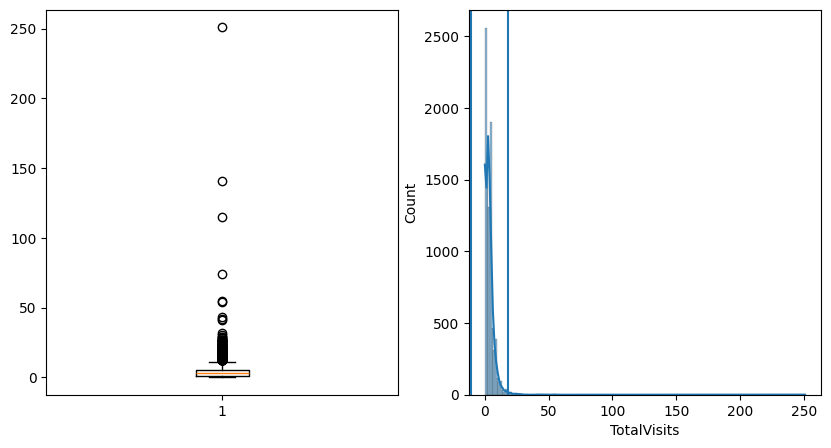

In [23]:
findOutliers(data, 'TotalVisits')

In [24]:
handleOutliers(data, 'TotalVisits')

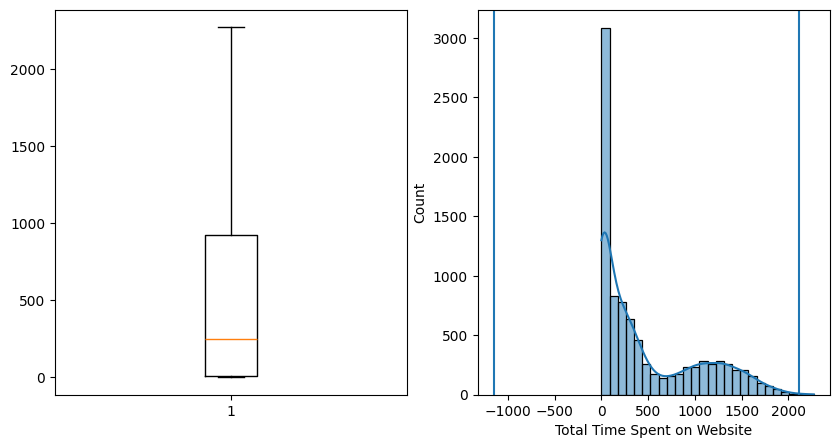

In [25]:
findOutliers(data, 'Total Time Spent on Website')

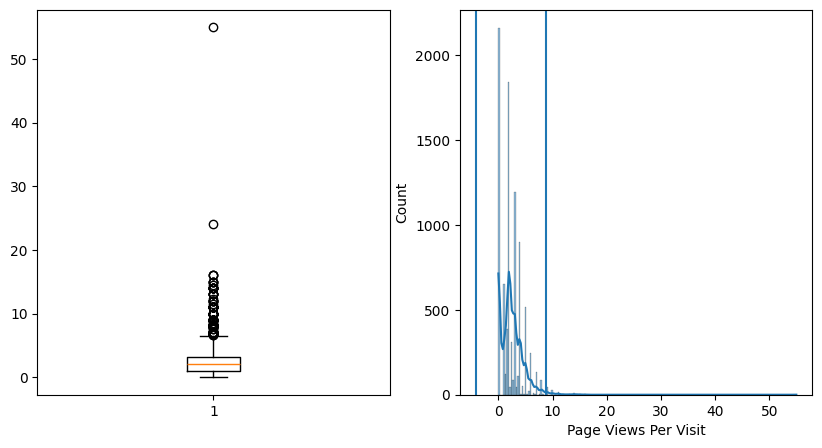

In [26]:
findOutliers(data, 'Page Views Per Visit')

In [27]:
handleOutliers(data, 'Page Views Per Visit')

In [28]:
data['Converted'].value_counts()

Converted
0    5639
1    3435
Name: count, dtype: int64

In [29]:
data.head()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Converted,Lead Origin_API,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,What is your current occupation_Businessman,What is your current occupation_Housewife,...,Specialization_Marketing Management,Specialization_Media and Advertising,Specialization_Not provided,Specialization_Operations Management,Specialization_Retail Management,Specialization_Rural and Agribusiness,Specialization_Select,Specialization_Services Excellence,Specialization_Supply Chain Management,Specialization_Travel and Tourism
0,0.0,0,0.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,5.0,674,2.5,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,2.0,1532,2.0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,305,1.0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,2.0,1428,1.0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [30]:
data.shape

(9074, 120)

In [31]:
x = data.drop('Converted',axis=1)
y = data['Converted']

In [32]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
x_sm, y_sm = sm.fit_resample(x,y)

In [33]:
y_sm.value_counts()

Converted
0    5639
1    5639
Name: count, dtype: int64

In [34]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_ss = ss.fit_transform(x_sm)

In [35]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_ss,y_sm, test_size=0.2, random_state=40)

In [36]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
from sklearn.model_selection import cross_validate
result = cross_validate(rf,x_train,y_train)
result

{'fit_time': array([0.69535017, 0.72518921, 0.68719745, 0.6928606 , 0.68804049]),
 'score_time': array([0.03040934, 0.03273129, 0.03081346, 0.0306325 , 0.03052664]),
 'test_score': array([0.9434903 , 0.95235457, 0.93569845, 0.93348115, 0.94124169])}

In [38]:
print('Validation score:', result['test_score'].mean())

Validation score: 0.9412532322754605


In [39]:
train_pred = rf.predict(x_train)

In [40]:
test_pred = rf.predict(x_test)

In [41]:
from sklearn.metrics import accuracy_score

In [42]:
print('Training score:',accuracy_score(y_train,train_pred))

Training score: 0.9922411882066061


In [43]:
print('Testing score:',accuracy_score(y_test,test_pred))

Testing score: 0.9441489361702128


In [44]:
# deployment

In [45]:
import pickle

In [46]:
with open('rf.pkl', 'wb') as f:
    pickle.dump(rf, f)

In [47]:
with open('x_ss.pkl', 'wb') as f:
    pickle.dump(ss, f)

In [48]:
cols=list(x.columns)

In [49]:
pickle.dump(cols, open('model_columns.pkl', 'wb'))